In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import os, sys
from pathlib import Path
import functools

import extra.data as ex
from extra.components import XGM
from extra.components import XrayPulses
from extra.data.components import AGIPD1M
from extra.geom import AGIPD_1MGeometry
from extra.data import by_index
import extra_speckle as esp
from extra_speckle.setup import Setup

from dask_jobqueue import SLURMCluster
from dask.distributed import Client
import dask.array as da

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import h5py
from pyFAI.integrator.azimuthal import AzimuthalIntegrator

In [2]:
q_rois = np.array([0.0225, 0.035, 0.045, 0.056, 0.065, 0.069, 0.075, 0.086])

In [20]:
PROPOSAL, RUN_NO = 10400, 464
GEOM_PATH = '/gpfs/exfel/exp/MID/202601/p010400/usr/geometry/geom_latest.geom'
MASK_PATH = '/gpfs/exfel/exp/MID/202601/p010400/usr/masks/mask_2026-05-19.npy'

In [13]:
def load_mean_img(
    run_no: int, proposal: int, trains_idxs: slice = np.s_[0]
) -> np.ndarray:
    run = ex.open_run(run=run_no, proposal=proposal, data="proc")
    exp_setup = Setup(
        run=run,
        detector="AGIPD 1M",
        configuration="SAXS",
        photon_energy=9.04,
        geom=GEOM_PATH,
        sdd=7531.5962,
        px=607.4598195630211,
        py=672.076693118667,
    )
    data = (
        AGIPD1M(run.select_trains(trains_idxs))
        .get_array("image.data", unstack_pulses=False)
        .astype("float32")
    )
    mask = AGIPD1M(run.select_trains(trains_idxs)).get_array(
        "image.mask", unstack_pulses=False
    )
    data.data[mask.data > 0] = np.nan
    mean_image = data.mean("train_pulse", skipna=True)
    return mean_image.data.copy(), exp_setup

In [14]:
run = ex.open_run(run=488, proposal=10400, data="proc")
data = (
    AGIPD1M(run.select_trains(0))
    .get_array("image.data", unstack_pulses=True)
    .astype("float32")
)
mask = AGIPD1M(run.select_trains(0)).get_array(
    "image.mask", unstack_pulses=True
)

/gpfs/exfel/u/usr/MID/202601/p010400/Shared/IA/MID-10400/notebooks
detector model: AGIPD 1M
Loading AGIPD 1M geometry from:
/gpfs/exfel/exp/MID/202601/p010400/usr/geometry/geom_latest.geom
`rep_rate` defined from the pulse pattern
Repetition rate: 2256944.44 Hz (source: AGIPD 1M)
Photon energy provided by the user
photon energy: 9.040 keV
Sample-detector distance (sdd): 7531.596 mm
Using user defined beam center position: (607.46, 672.08)
-------------------



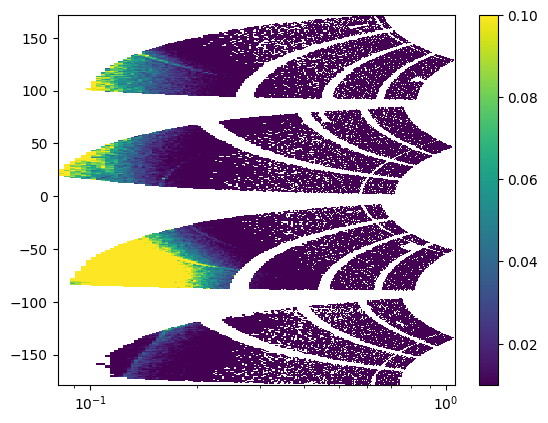

In [22]:
from extra_speckle import saxs

mean_image_bg, exp_setup = load_mean_img(464, PROPOSAL)
result_bg = saxs.get(
    mean_image_bg,
    exp_setup,
    unit="q_nm^-1",
    method="2d",
)
result_bg.data[result_bg.data == 0] = np.nan
plt.pcolormesh(
    result_bg.q.values, result_bg.chi.values, result_bg.data.T, vmin=1e-2, vmax=0.1
)
plt.colorbar()
plt.xscale("log")
plt.show()
np.save(f"cake_r{RUN_NO}.npy", result_bg.data.T)

<Axes: xlabel='metres', ylabel='metres'>

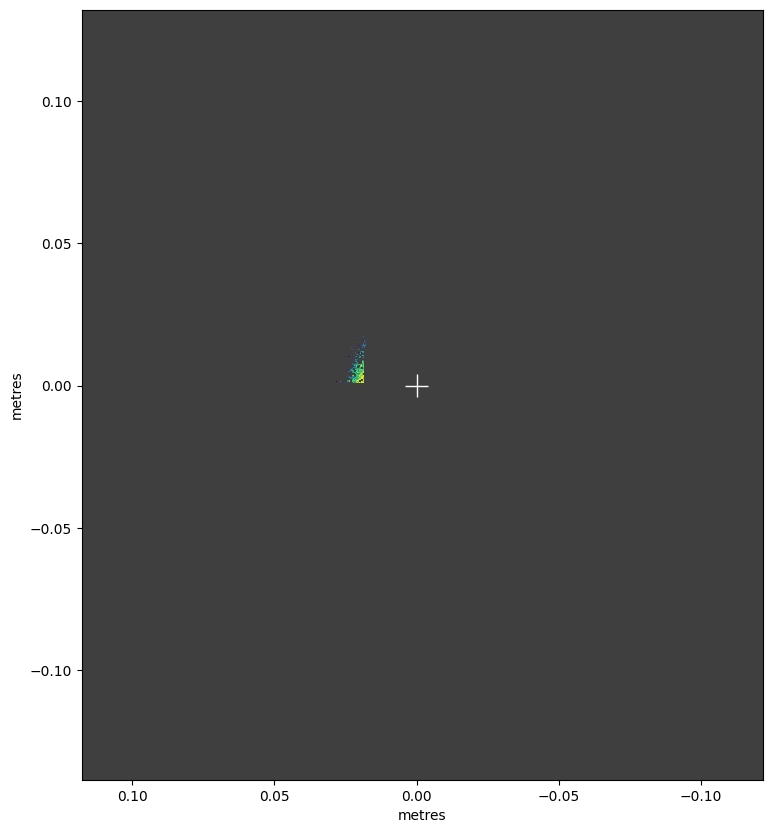

In [23]:
def visualise_mask(mask_arr):
    img = mean_image_bg * (~mask_arr.astype(bool))
    img[img <= 0] = np.nan
    return AGIPD_1MGeometry.from_crystfel_geom(GEOM_PATH).plot_data(
        # converting to float allows gaps to be distinguished as NaN.
        img,
        colorbar=False,
        axis_units="m",
        norm="log",
        vmin=1e-2,
        vmax=0.05,
    )


geom = AGIPD_1MGeometry.from_crystfel_geom(GEOM_PATH)
geom = geom.offset((-8e-3, 1e-3))
pixpos = geom.get_pixel_positions()
px, py, pz = np.moveaxis(pixpos, -1, 0)  # Separate x, y, z coordinates
radius = np.sqrt(px**2 + py**2)
# px.shape  # (modules, slow scan, fast scan)

rect_mask1 = (-0.042 < px) & (px < 0.00) & (0.00 < py) & (py < 0.06)
rect_mask2 = (0.00 < px) & (px < 0.03) & (-0.059 < py) & (py < 0.00)
rect_mask3 = (-0.20 < px) & (px < 0.20) & (-0.02 < py) & (py < 0.003)
rect_mask4 = (0.00 < px) & (px < 0.005) & (-0.035 < py) & (py < 0.00)
angle = np.arctan2(py, px)
wedge_mask1 = (angle > np.pi * 4 / 8) & (angle > -np.pi * 4 / 8)
ring_mask1 = (0.00 < radius) & (radius < 0.06)
wedge_mask2 = (-np.deg2rad(100) < angle) & (angle < np.deg2rad(0))
ring_mask2 = (0.00 < radius) & (radius < 0.06)
wedge_mask3 = (-np.deg2rad(90) > angle) & (angle > -np.deg2rad(180))
ring_mask3 = (0.00 < radius) & (radius < 0.06)
wedge_mask4 = (np.deg2rad(60) < angle) & (angle < np.deg2rad(90))
ring_mask4 = (0.00 < radius) & (radius < 0.06)

mask_rect = False
mask_wedge1 = True
mask_wedge2 = True
mask_wedge3 = True
mask_wedge4 = True
apply_mask1 = np.load(MASK_PATH) | rect_mask1 if mask_rect else np.load(MASK_PATH)
apply_mask2 = np.load(MASK_PATH) | rect_mask2 if mask_rect else np.load(MASK_PATH)
apply_mask3 = np.load(MASK_PATH) | rect_mask3 if mask_rect else np.load(MASK_PATH)
apply_mask4 = np.load(MASK_PATH) | rect_mask4 if mask_rect else np.load(MASK_PATH)
apply_wedge1 = (
    np.load(MASK_PATH) | (wedge_mask1 & ring_mask1)
    if mask_wedge1
    else np.load(MASK_PATH)
)
apply_wedge2 = (
    np.load(MASK_PATH) | (wedge_mask2 & ring_mask2)
    if mask_wedge2
    else np.load(MASK_PATH)
)
apply_wedge3 = (
    np.load(MASK_PATH) | (wedge_mask3 & ring_mask3)
    if mask_wedge3
    else np.load(MASK_PATH)
)
apply_wedge4 = (
    np.load(MASK_PATH) | (wedge_mask4 & ring_mask4)
    if mask_wedge4
    else np.load(MASK_PATH)
)
mask_overlay = (
    apply_mask1
    | apply_mask2
    | apply_mask3
    | apply_mask4
    | apply_wedge1
    | apply_wedge2
    | apply_wedge3
    | apply_wedge4
)
# np.save(
#     "/gpfs/exfel/u/usr/MID/202601/p010400/masks/mask_2026-09-08_AGIPD_SAXS.npy",
#     mask_overlay,
# )
# visualise_mask(np.load("custom_agipd_mask.npy"))
visualise_mask(mask_overlay)

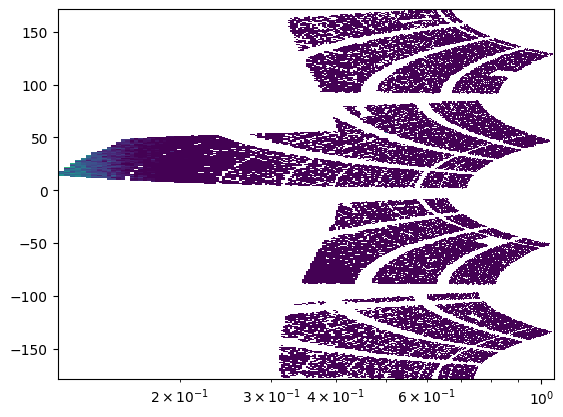

In [24]:
result_bg_1d = saxs.get(
    mean_image_bg,
    exp_setup,
    unit="q_nm^-1",
    method="1d",
    mask=mask_overlay,
)
result_bg_1d.data[result_bg_1d.data == 0] = np.nan
# plt.loglog(result_bg_1d.q.values, result_bg_1d.data.T)
# plt.show()

result_bg_2d = saxs.get(
    mean_image_bg,
    exp_setup,
    unit="q_nm^-1",
    method="2d",
    mask=mask_overlay,
)
result_bg_2d.data[result_bg_2d.data == 0] = np.nan
plt.pcolormesh(
    result_bg_2d.q.values, result_bg_2d.chi.values, result_bg_2d.data.T, vmin=1e-2, vmax=0.1
)
plt.xscale("log")

/gpfs/exfel/u/usr/MID/202601/p010400/Shared/IA/MID-10400/notebooks
detector model: AGIPD 1M
Loading AGIPD 1M geometry from:
/gpfs/exfel/exp/MID/202601/p010400/usr/geometry/geom_latest.geom
`rep_rate` defined from the pulse pattern
Repetition rate: 2256944.44 Hz (source: AGIPD 1M)
Photon energy provided by the user
photon energy: 9.040 keV
Sample-detector distance (sdd): 7531.596 mm
Using user defined beam center position: (607.46, 672.08)
-------------------



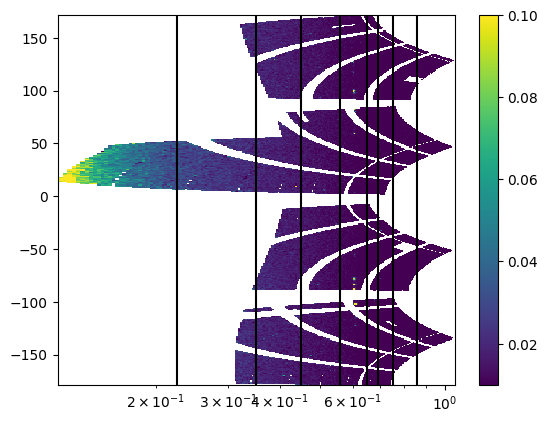

In [25]:
RUN_NO = 488
mean_image, exp_setup = load_mean_img(RUN_NO, PROPOSAL)

result = saxs.get(mean_image, exp_setup, unit="q_nm^-1", method="2d", mask=mask_overlay)
for roi in q_rois:
    plt.axvline(roi*10, color="k")
result.data[result.data == 0] = np.nan
plt.pcolormesh(result.q.values, result.chi.values, result.data.T, vmin=1e-2, vmax=0.1)
plt.colorbar()
plt.xscale("log")
plt.show()

<Axes: xlabel='metres', ylabel='metres'>

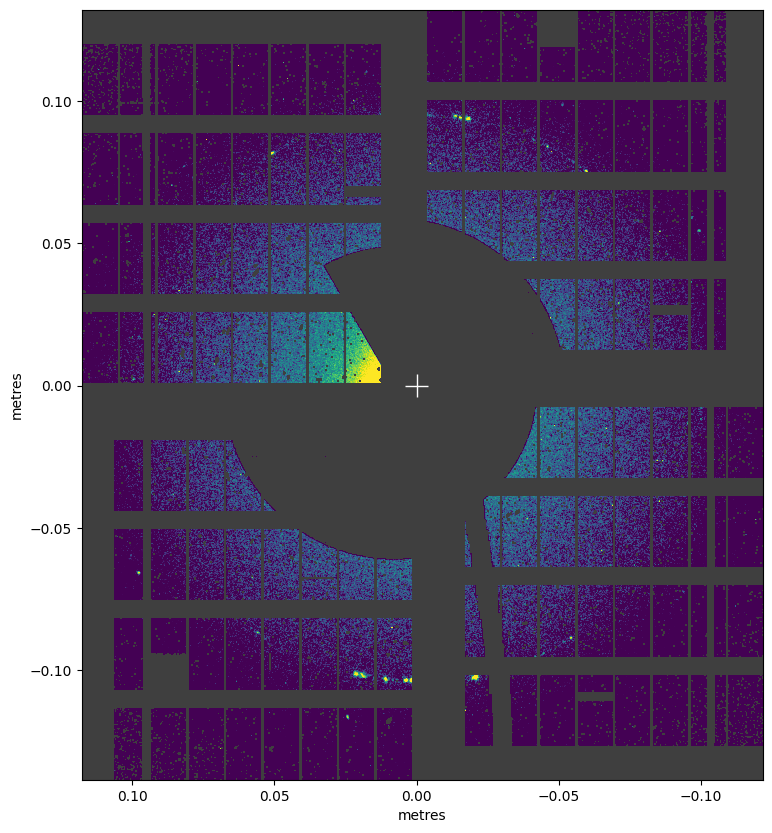

In [26]:
def visualise_mask(mask_arr):
    return AGIPD_1MGeometry.from_crystfel_geom(GEOM_PATH).plot_data(
        # converting to float allows gaps to be distinguished as NaN.
        # mean_image * (~mask_arr.astype(bool)),
        mean_image * (~np.load("/gpfs/exfel/u/usr/MID/202601/p010400/masks/mask_2026-09-08_AGIPD_SAXS.npy").astype(bool)),
        colorbar=False,
        axis_units="m",
        norm="log",
        vmin=1e-2,
        vmax=0.1,
    )


visualise_mask(mask_overlay)

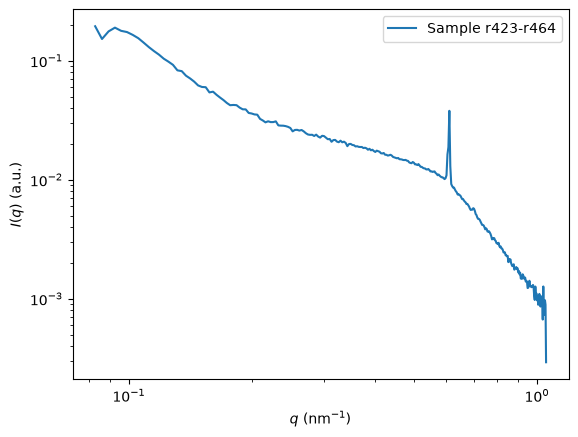

In [13]:
result_1d = saxs.get(
    mean_image, exp_setup, unit="q_nm^-1", method="1d", mask=mask_overlay
)
result_1d.data[result_1d.data == 0] = np.nan
# plt.loglog(result_1d.q.values, result_1d.data.T, label="Sample r423")
# plt.loglog(result_bg_1d.q.values, result_bg_1d.data.T, label="BG r464")
plt.loglog(
    result_1d.q.values,
    result_1d.data.T,# - result_bg_1d.data.T*0.4,
    label="Sample r423-r464",
)
# plt.loglog(
#     result_1d.q.values,
#     result_bg_1d.data.T,
# )
# for roi in q_rois:
#     plt.axvline(roi*10)
# plt.ylim(
#     1e-3,
# )
plt.ylabel("$I(q)~$(a.u.)")
plt.xlabel("$q~$(nm$^{-1}$)")
plt.legend()
plt.show()

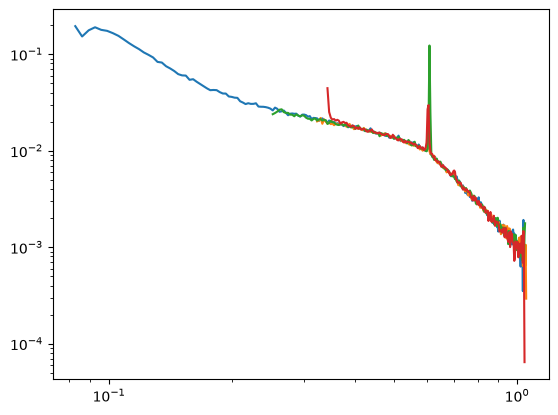

In [245]:
for r in [(0,90), (90,180), (180,270), (270,360)]:
    result_1d = saxs.get(
        mean_image, exp_setup, unit="q_nm^-1", method="1d", mask=mask_overlay,
        azimuth_range=r
    )
    result_1d.data[result_1d.data == 0] = np.nan
    plt.loglog(
        result_1d.q.values,
        result_1d.data.T,# - result_bg_1d.data.T*0.4,
        label="Sample r423-r464",
    )
plt.show()